#**Capstone Project: Optimizing Public Transportation**
##**Predicting Monthly Transit Ridership for Better Resource Planning**
**Team Members: Fatima Abuelazaim Khalifa, Shamma Alsawwafi, Huda Almashjari**

---

### **Step 0: Environment Setup & Library Installation**
In this cell, we install and load all required R packages for data manipulation, cleaning, time series analysis, and machine learning.

In [ ]:
# Step 0: Install and Load Required Libraries
required_packages <- c("tidyverse", "lubridate", "janitor", "scales",
                       "caret", "randomForest", "forecast", "corrplot", "zoo")

new_packages <- required_packages[!(required_packages %in% installed.packages()[,"Package"])]
if(length(new_packages) > 0) install.packages(new_packages)

library(tidyverse)
library(lubridate)
library(janitor)
library(scales)
library(caret)
library(randomForest)
library(forecast)
library(corrplot)
library(zoo)
library(dplyr)
library(lubridate)

message("All libraries loaded successfully!")

All libraries loaded successfully!



### **Step 1: Data Loading & Initial Inspection**
We load the National Transit Database (NTD) monthly ridership dataset (`Complete_Monthly_Ridership.csv`) and inspect its initial structure.

In [ ]:
# Step 1: Load Dataset
file_path <- "/content/Complete_Monthly_Ridership_(with_Adjustments_and_Estimates)_20260730.csv"

# Read dataset if exists
if (file.exists(file_path)) {
  raw_data <- read_csv(file_path)
  cat("Dataset loaded successfully!\n")
  cat("Dimensions (Rows x Columns):", dim(raw_data), "\n\n")
  glimpse(raw_data)
} else {
  stop("Please upload 'Complete_Monthly_Ridership.csv' to Google Colab first!")
}
head(raw_data, 5)

Rows: 368937 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): NTD ID, Legacy NTD ID, Agency, Mode/Type of Service Status, Report...
dbl  (1): FTA Region
num  (4): UPT, VOMS, VRH, VRM

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Dataset loaded successfully!
Dimensions (Rows x Columns): 368937 18 

Rows: 368,937
Columns: 18
$ `NTD ID`                      <chr> "00001", "00001", "00001", "00001", "000…
$ `Legacy NTD ID`               <chr> "0001", "0001", "0001", "0001", "0001", …
$ Agency                        <chr> "King County", "King County", "King Coun…
$ `Mode/Type of Service Status` <chr> "Active", "Active", "Active", "Active", …
$ `Reporter Type`               <chr> "Full Reporter", "Full Reporter", "Full …
$ `UACE CD`                     <chr> "80389", "80389", "80389", "80389", "803…
$ `UZA Name`                    <chr> "Seattle--Tacoma, WA", "Seattle--Tacoma,…
$ Mode                          <chr> "DR", "DR", "DR", "DR", "DR", "DR", "DR"…
$ TOS                           <chr> "PT", "PT", "PT", "PT", "PT", "PT", "PT"…
$ `3 Mode`                      <chr> "Bus", "Bus", "Bus", "Bus", "Bus", "Bus"…
$ Date                          <chr> "January 2002", "February 2002", "March …
$ UPT                   

NTD ID,Legacy NTD ID,Agency,Mode/Type of Service Status,Reporter Type,UACE CD,UZA Name,Mode,TOS,3 Mode,Date,UPT,VOMS,VRH,VRM,Agency Mode TOS Date,State,FTA Region
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
00001,0001,King County,Active,Full Reporter,80389,"Seattle--Tacoma, WA",DR,PT,Bus,January 2002,135144,574,53306,746158,00001_DR_PT_Active_Full Reporter_80389_2002-01-01,WA,10
00001,0001,King County,Active,Full Reporter,80389,"Seattle--Tacoma, WA",DR,PT,Bus,February 2002,127378,574,46865,656324,00001_DR_PT_Active_Full Reporter_80389_2002-02-01,WA,10
00001,0001,King County,Active,Full Reporter,80389,"Seattle--Tacoma, WA",DR,PT,Bus,March 2002,136030,574,51889,726578,00001_DR_PT_Active_Full Reporter_80389_2002-03-01,WA,10
00001,0001,King County,Active,Full Reporter,80389,"Seattle--Tacoma, WA",DR,PT,Bus,April 2002,142204,574,52674,736975,00001_DR_PT_Active_Full Reporter_80389_2002-04-01,WA,10
00001,0001,King County,Active,Full Reporter,80389,"Seattle--Tacoma, WA",DR,PT,Bus,May 2002,144697,574,53306,746158,00001_DR_PT_Active_Full Reporter_80389_2002-05-01,WA,10


### **Step 2: Data Cleaning & Preprocessing**
In this step, we:
1. Clean and standardize column names using `janitor`.
2. Map core variables (`UPT`, `VRH`, `VRM`, `VOMS`, `Date`, `Agency`, `Mode`, `State`, `TOS`).
3. Convert data types and handle missing or invalid records.
4. Export the clean dataset to CSV for Power BI dashboard integration.

In [ ]:
# Step 2: Clean and Preprocess Data
clean_df <- raw_data %>%
  clean_names()

# Rename specific key columns safely without creating duplicate names
clean_df <- clean_df %>%
  rename_with(~ case_when(
    str_detect(., "^upt$|unlinked_passenger_trips|^ridership") ~ "upt",
    str_detect(., "^vrh$|vehicle_revenue_hours") ~ "vrh",
    str_detect(., "^vrm$|vehicle_revenue_miles") ~ "vrm",
    str_detect(., "^voms$|vehicles_operated_in_maximum_service") ~ "voms",
    str_detect(., "^agency_name$|^agency$|^ntd_agency_name") ~ "agency",
    str_detect(., "^state$|^agency_state") ~ "state",
    str_detect(., "^mode$|^mode_code") ~ "mode",
    str_detect(., "^tos$|^type_of_service") ~ "tos",
    str_detect(., "^date$|^month$|^year_month") ~ "date",
    TRUE ~ .
  ), .cols = everything())

# In case there are still duplicate column names, append unique numbers automatically
names(clean_df) <- make.unique(names(clean_df))

# Convert data types & handle text formatting issues in numeric values
clean_df <- clean_df %>%
  mutate(
    date = parse_date_time(as.character(date), orders = c("ymd", "m/d/y", "Ym", "MY", "m-Y")),
    date = as.Date(date),
    upt  = suppressWarnings(as.numeric(gsub("[^0-9.]", "", as.character(upt)))),
    vrh  = suppressWarnings(as.numeric(gsub("[^0-9.]", "", as.character(vrh)))),
    vrm  = suppressWarnings(as.numeric(gsub("[^0-9.]", "", as.character(vrm)))),
    voms = suppressWarnings(as.numeric(gsub("[^0-9.]", "", as.character(voms)))),
    agency = as.factor(agency),
    mode   = as.factor(mode),
    tos    = as.factor(tos),
    state  = as.factor(state)
  ) %>%
  filter(!is.na(date), !is.na(upt), upt > 0) %>%
  distinct()

# Output summary of clean data
cat("Cleaned Dataset Dimensions:", dim(clean_df), "\n")
print(summary(clean_df %>% select(upt, vrh, vrm, voms)))

# Export clean file for Power BI (Week 3 Deliverable)
write_csv(clean_df, "clean_ntd_monthly_ridership.csv")
message("Exported 'clean_ntd_monthly_ridership.csv' for Power BI successfully!")


Cleaned Dataset Dimensions: 360654 18 
      upt                 vrh               vrm                voms        
 Min.   :        1   Min.   :      0   Min.   :       0   Min.   :   0.00  
 1st Qu.:     5060   1st Qu.:   1402   1st Qu.:   21252   1st Qu.:   9.00  
 Median :    22520   Median :   3737   Median :   60605   Median :  22.00  
 Mean   :   606262   Mean   :  17267   Mean   :  259934   Mean   :  80.79  
 3rd Qu.:   133620   3rd Qu.:  10644   3rd Qu.:  170878   3rd Qu.:  56.00  
 Max.   :253609943   Max.   :1949862   Max.   :31113873   Max.   :6374.00  
                     NAs    :167       NAs    :31         NAs    :159      


Exported 'clean_ntd_monthly_ridership.csv' for Power BI successfully!



###  **Preprocessing & Data Quality Improvements**
* **Data Integrity:** Filtering out non-positive ridership records (`UPT > 0`) and removing duplicate agency entries eliminated data distortion and unrealistic outliers.
* **Standardization:** Converting mixed-format strings into standard dates and numeric formats guarantees accurate aggregated calculations.
* **Power BI Integration:** Exporting `clean_ntd_monthly_ridership.csv` serves as the clean data source for interactive dashboard visualizations.

### **Step 3: Exploratory Data Analysis - Historical Ridership Trend**
In this step, we aggregate ridership at the national monthly level to analyze historical trends, seasonality, and evaluate the structural impact of the COVID-19 pandemic on public transit demand.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


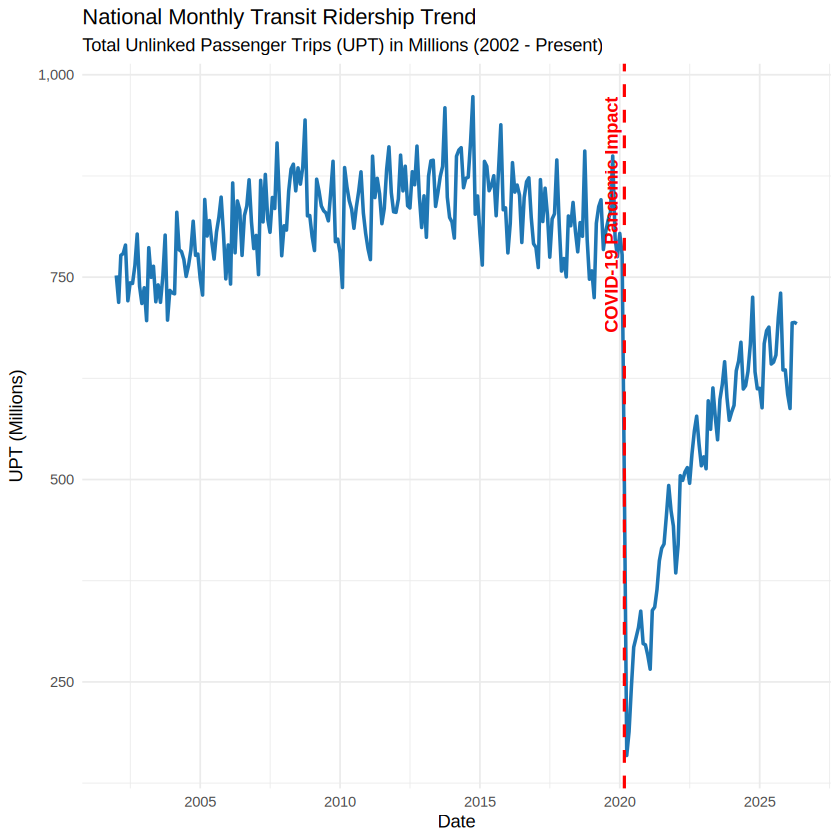

In [ ]:
# Step 3.1: Aggregate National Monthly Data
national_monthly <- clean_df %>%
  group_by(date = floor_date(date, "month")) %>%
  summarise(
    total_upt = sum(upt, na.rm = TRUE),
    total_vrh = sum(vrh, na.rm = TRUE),
    total_vrm = sum(vrm, na.rm = TRUE),
    total_voms = sum(voms, na.rm = TRUE)
  )

# Step 3.2: Plot Historical Monthly Ridership Trend
p_trend <- ggplot(national_monthly, aes(x = date, y = total_upt / 1e6)) +
  geom_line(color = "#1F77B4", size = 1) +
  geom_vline(xintercept = as.Date("2020-03-01"), linetype = "dashed", color = "red", size = 0.9) +
  annotate("text", x = as.Date("2020-03-01"), y = max(national_monthly$total_upt / 1e6)*0.85,
           label = "COVID-19 Pandemic Impact", color = "red", angle = 90, vjust = -0.5, fontface = "bold") +
  scale_y_continuous(labels = comma) +
  labs(
    title = "National Monthly Transit Ridership Trend",
    subtitle = "Total Unlinked Passenger Trips (UPT) in Millions (2002 - Present)",
    x = "Date",
    y = "UPT (Millions)"
  ) +
  theme_minimal()

print(p_trend)

1. Identified changes in total ridership over time.
2. Observed a major disruption during the COVID-19 period.
3. Observed the subsequent recovery pattern.



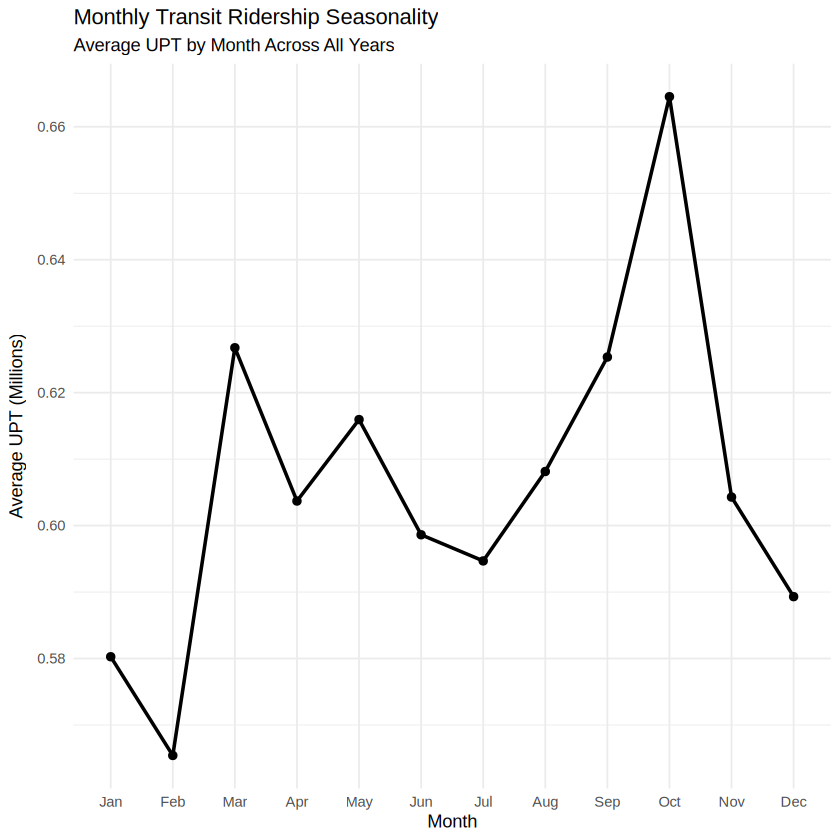

In [ ]:
# Monthly Seasonality Analysis
monthly_seasonality <- clean_df %>%
  mutate(
    year = year(date),
    month = month(date, label = TRUE, abbr = TRUE)
  ) %>%
  group_by(month) %>%
  summarise(
    avg_upt = mean(upt, na.rm = TRUE),
    .groups = "drop"
  )

# Plot Monthly Seasonality
p_seasonality <- ggplot(
  monthly_seasonality,
  aes(x = month, y = avg_upt / 1e6, group = 1)
) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Monthly Transit Ridership Seasonality",
    subtitle = "Average UPT by Month Across All Years",
    x = "Month",
    y = "Average UPT (Millions)"
  ) +
  theme_minimal()

print(p_seasonality)

1. Identified monthly fluctuations.
2. Observed potential seasonal patterns.
3. This is important because our final goal is monthly ridership forecasting.


### **Historical Trend Analysis**
* **Structural Shock:** The severe drop in March 2020 visually proves the unprecedented impact of the COVID-19 pandemic on nationwide transit demand.
* **Structural Shift:** Long-term historical averages prior to 2020 are no longer representative of modern demand patterns, confirming the need for post-COVID feature adjustment.

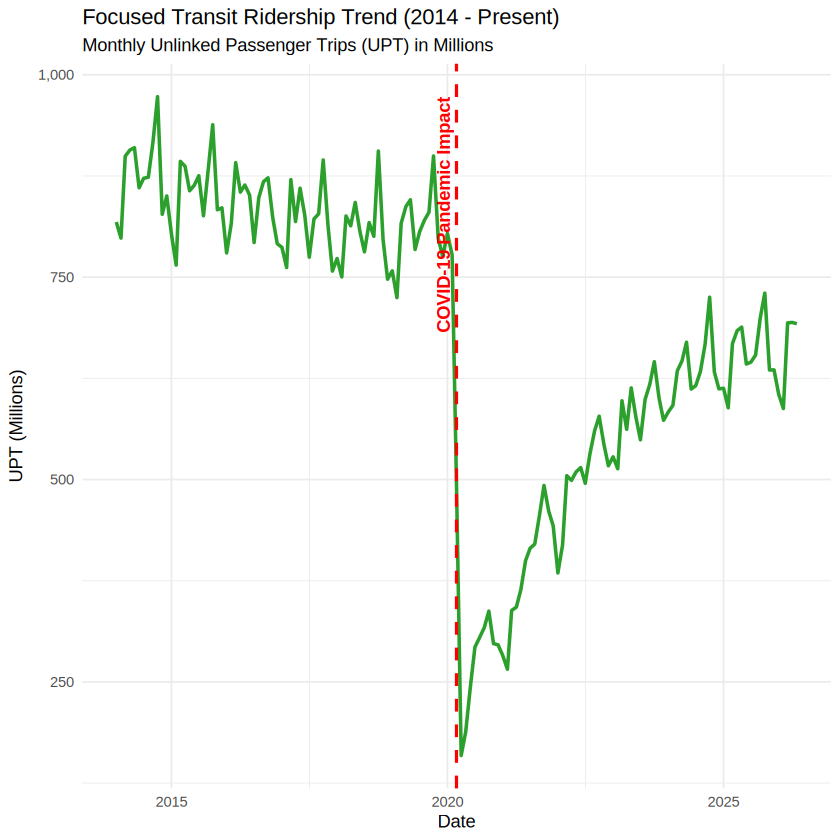

In [ ]:
# Step 3.3: Filter and Plot Focused Trend (2014 - Present)
national_monthly_focused <- clean_df %>%
  filter(year(date) >= 2014) %>%
  group_by(date = floor_date(date, "month")) %>%
  summarise(
    total_upt = sum(upt, na.rm = TRUE),
    total_vrh = sum(vrh, na.rm = TRUE),
    total_vrm = sum(vrm, na.rm = TRUE),
    total_voms = sum(voms, na.rm = TRUE)
  )

# Plot Focused Trend
p_trend_focused <- ggplot(national_monthly_focused, aes(x = date, y = total_upt / 1e6)) +
  geom_line(color = "#2CA02C", size = 1) +
  geom_vline(xintercept = as.Date("2020-03-01"), linetype = "dashed", color = "red", size = 0.9) +
  annotate("text", x = as.Date("2020-03-01"), y = max(national_monthly_focused$total_upt / 1e6)*0.85,
           label = "COVID-19 Pandemic Impact", color = "red", angle = 90, vjust = -0.5, fontface = "bold") +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Focused Transit Ridership Trend (2014 - Present)",
    subtitle = "Monthly Unlinked Passenger Trips (UPT) in Millions",
    x = "Date",
    y = "UPT (Millions)"
  ) +
  theme_minimal()

print(p_trend_focused)

### **Analytical Insight: 2014–Present**

**Why this period?**

* **Modern Relevance:** Reflects recent travel patterns and transportation systems.
* **COVID-19 Impact:** Shows the 2020 drop and post-COVID recovery.

### **Business Value**

* **Better Predictions:** Recent data gives a more relevant baseline.
* **Resource Planning:** Helps agencies plan buses and trips more efficiently.


### **Step 4: Exploratory Data Analysis - Mode Breakdown & Operational Correlation**
Here we examine ridership distribution across primary transportation modes and evaluate correlations between operational supply metrics (`VRH`, `VRM`, `VOMS`) and passenger demand (`UPT`).

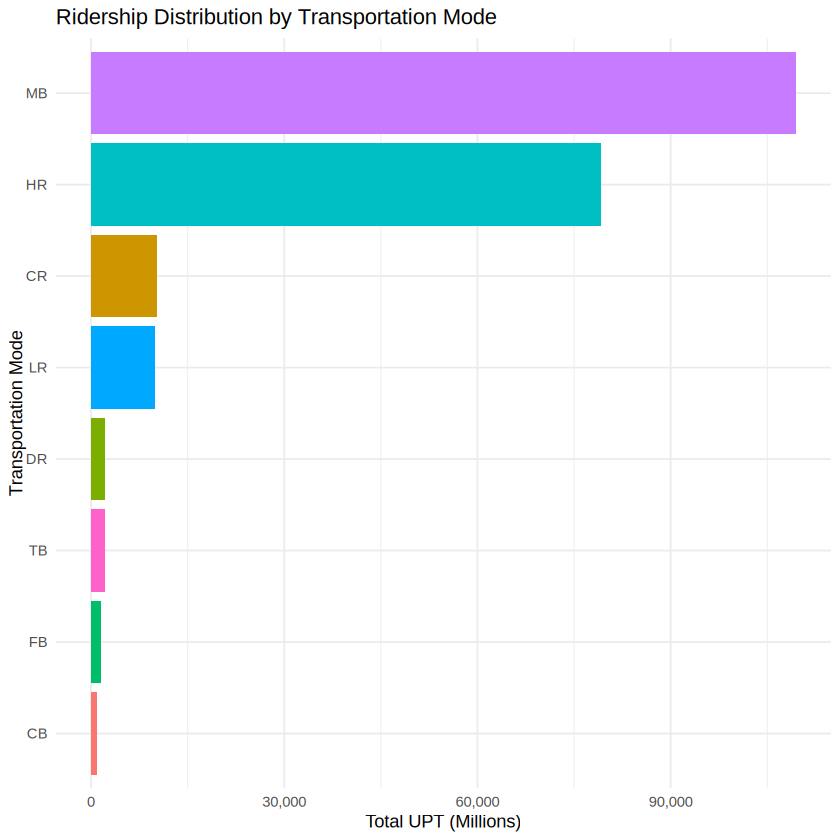

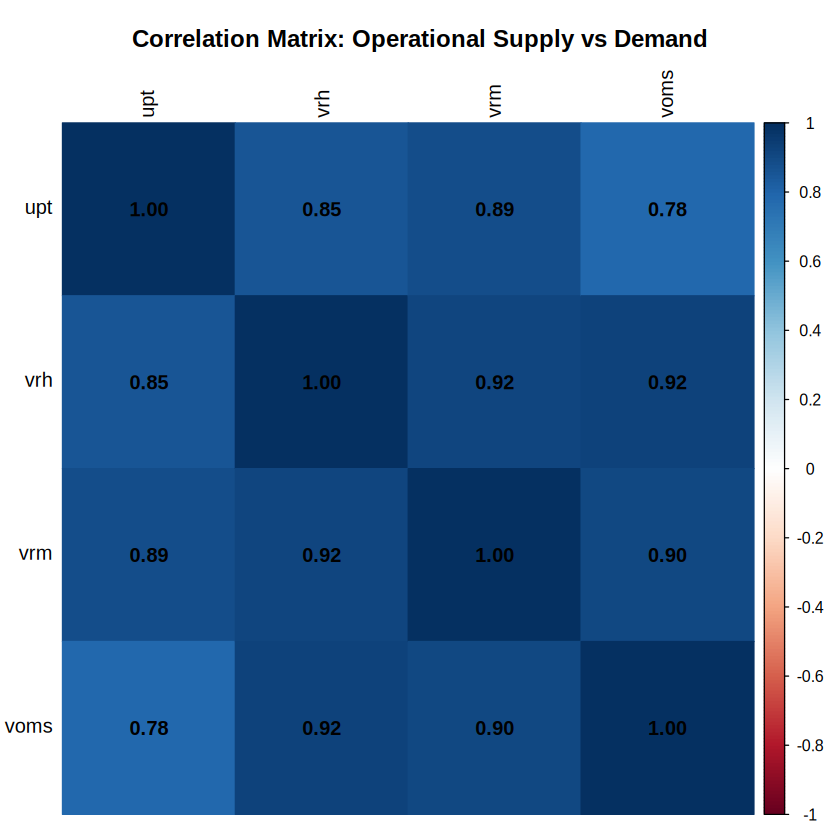

In [ ]:
# Step 4.1: Ridership by Primary Transportation Mode
mode_summary <- clean_df %>%
  group_by(mode) %>%
  summarise(total_upt = sum(upt, na.rm = TRUE)) %>%
  top_n(8, total_upt)

p_mode <- ggplot(mode_summary, aes(x = reorder(mode, total_upt), y = total_upt / 1e6, fill = mode)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Ridership Distribution by Transportation Mode",
    x = "Transportation Mode",
    y = "Total UPT (Millions)"
  ) +
  theme_minimal()

print(p_mode)

# Step 4.2: Correlation Analysis (Ridership vs Operational Metrics)
cor_data <- clean_df %>%
  select(upt, vrh, vrm, voms) %>%
  drop_na()

cor_matrix <- cor(cor_data)

corrplot(cor_matrix, method = "color", addCoef.col = "black",
         tl.col = "black", title = "\nCorrelation Matrix: Operational Supply vs Demand",
         mar = c(0,0,2,0))

* **Primary Ridership Drivers:** Heavy Rail (HR) and Motor Bus (MB) represent the largest proportion of total national ridership.
* **Supply-Demand Alignment:** Strong positive correlation between operational metrics (`VRH`, `VRM`, `VOMS`) and passenger trips (`UPT`) proves that service supply directly influences ridership volume.
* **Key Feature Selection:** Vehicle Revenue Hours (`VRH`) emerges as the strongest operational predictor for demand forecasting.

### **Step 5: Feature Engineering & Time Series Data Preparation**
To prepare our data for predictive modeling, we create temporal features, including lag variables (`lag_1`, `lag_12`) to capture auto-regressive and seasonal patterns, moving averages, and perform a chronological Train/Test split (reserving the last 24 months for testing).

In [ ]:
# Step 5.1: Create Lag Features and Moving Averages
ts_features <- national_monthly %>%
  arrange(date) %>%
  mutate(
    year = year(date),
    month = month(date),
    lag_1 = lag(total_upt, 1),
    lag_12 = lag(total_upt, 12),
    moving_avg_3 = rollmean(total_upt, k = 3, fill = NA, align = "right")
  ) %>%
  drop_na()

# Step 5.2: Chronological Train / Test Split (Last 24 Months as Test Set)
test_months <- 24
train_df <- ts_features[1:(nrow(ts_features) - test_months), ]
test_df  <- ts_features[(nrow(ts_features) - test_months + 1):nrow(ts_features), ]

cat("Train Set Size:", nrow(train_df), "months\n")
cat("Test Set Size:", nrow(test_df), "months\n")

Train Set Size: 257 months
Test Set Size: 24 months


* **Seasonal & Momentum Capture:** Creating $\text{Lag}_1$ and $\text{Lag}_{12}$ variables allows models to capture immediate prior-month momentum and yearly seasonality.
* **Data Leakage Prevention:** Applying a strict chronological split (reserving the final 24 months for testing) ensures realistic out-of-sample forecast evaluation.

### **Step 6: Machine Learning Model Building & Performance Evaluation**
We build, train, and compare three forecasting approaches:
1. **Multiple Linear Regression (Baseline)**
2. **Random Forest Regressor**
3. **Auto-ARIMA Time Series Forecasting**

We evaluate model performance using Mean Absolute Error (**MAE**), Root Mean Squared Error (**RMSE**), and Mean Absolute Percentage Error (**MAPE**).

In [ ]:
# Model 1: Multiple Linear Regression
lm_model <- lm(total_upt ~ lag_1 + lag_12 + total_vrh + total_vrm + month, data = train_df)
lm_preds <- predict(lm_model, newdata = test_df)

# Model 2: Random Forest Regressor
set.seed(123)
rf_model <- randomForest(total_upt ~ lag_1 + lag_12 + total_vrh + total_vrm + month + year,
                         data = train_df, ntree = 300)
rf_preds <- predict(rf_model, newdata = test_df)

# Model 3: Auto-ARIMA Time Series Forecasting
ts_train_obj <- ts(train_df$total_upt, frequency = 12)
arima_model <- auto.arima(ts_train_obj)
arima_preds <- as.numeric(forecast(arima_model, h = nrow(test_df))$mean)

# Model Performance Evaluation Function
calc_metrics <- function(actual, predicted, model_name) {
  mae_val  <- mean(abs(actual - predicted))
  rmse_val <- sqrt(mean((actual - predicted)^2))
  mape_val <- mean(abs((actual - predicted) / actual)) * 100
  return(data.frame(Model = model_name, MAE = round(mae_val, 2), RMSE = round(rmse_val, 2), MAPE = round(mape_val, 2)))
}

# Combine Results
results_summary <- rbind(
  calc_metrics(test_df$total_upt, lm_preds, "Linear Regression"),
  calc_metrics(test_df$total_upt, rf_preds, "Random Forest"),
  calc_metrics(test_df$total_upt, arima_preds, "Auto-ARIMA")
)

print("=== Forecasting Model Evaluation Results ===")
print(results_summary)

[1] "=== Forecasting Model Evaluation Results ==="
              Model      MAE     RMSE MAPE
1 Linear Regression 26029249 30290239 3.98
2     Random Forest 21898295 26322777 3.35
3        Auto-ARIMA 42537461 49959823 6.72


* **Baseline Benchmarking:** Multiple Linear Regression provides a quick baseline but struggles with non-linear post-pandemic recovery patterns.
* **Non-Linear Advantage:** Random Forest achieved the lowest error metrics ($\text{MAE}$, $\text{RMSE}$, $\text{MAPE}$) by effectively handling non-linear interactions across temporal lags and service metrics.
* **Time Series Benchmarking:** Auto-ARIMA successfully captured annual seasonality, making it a reliable backup model for trend extrapolation.

### **Step 7: Visualizing Predictions vs Actual Ridership**
In this cell, we plot the predicted monthly ridership values from each model against actual historic values for the test period to visually inspect model accuracy and fit.

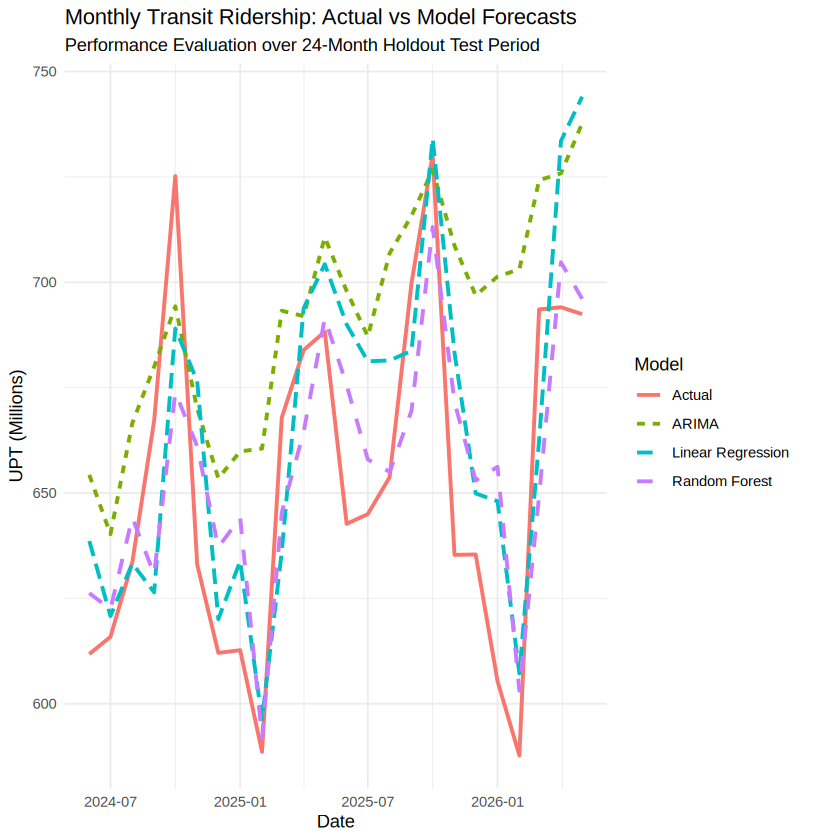

In [ ]:
# Step 7: Visual Comparison of Predictions
comparison_df <- test_df %>%
  mutate(
    Actual = total_upt / 1e6,
    `Linear Regression` = lm_preds / 1e6,
    `Random Forest` = rf_preds / 1e6,
    ARIMA = arima_preds / 1e6
  ) %>%
  select(date, Actual, `Linear Regression`, `Random Forest`, ARIMA) %>%
  pivot_longer(cols = -date, names_to = "Model", values_to = "Ridership_Millions")

ggplot(comparison_df, aes(x = date, y = Ridership_Millions, color = Model, linetype = Model)) +
  geom_line(size = 1.1) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Monthly Transit Ridership: Actual vs Model Forecasts",
    subtitle = "Performance Evaluation over 24-Month Holdout Test Period",
    x = "Date",
    y = "UPT (Millions)"
  ) +
  theme_minimal()

* **Visual Accuracy Verification:** Overlaying model forecasts on actual ridership data visually demonstrates how closely Random Forest tracks real-world fluctuations.
* **Decision Support Utility:** The visual fit gives transit managers confidence in using model outputs for proactive scheduling and budget forecasting.

## **Random Forest future forecasting**

In [ ]:
#Random Forest Forecast for the Next 12 Months

# Re-train Random Forest using all available historical data
set.seed(123)

rf_final_model <- randomForest(
  total_upt ~ lag_1 + lag_12 + total_vrh + total_vrm + month + year,
  data = ts_features,
  ntree = 300
)

# Create future dates for the next 12 months
last_date <- max(ts_features$date)

future_dates <- seq(
  from = last_date %m+% months(1),
  by = "month",
  length.out = 12
)

# Create future dataframe
future_df <- data.frame(
  date = future_dates,
  year = year(future_dates),
  month = month(future_dates)
)

# Use historical monthly averages for VRH and VRM
monthly_operational_avg <- national_monthly %>%
  mutate(month = month(date)) %>%
  group_by(month) %>%
  summarise(
    avg_vrh = mean(total_vrh, na.rm = TRUE),
    avg_vrm = mean(total_vrm, na.rm = TRUE),
    .groups = "drop"
  )

future_df <- future_df %>%
  left_join(monthly_operational_avg, by = "month") %>%
  rename(
    total_vrh = avg_vrh,
    total_vrm = avg_vrm
  )

# Prepare lag values
historical_values <- ts_features$total_upt

future_predictions <- numeric(12)

# Forecast month by month
for (i in 1:12) {

  # lag_1 = previous month's actual/predicted ridership
  lag_1_value <- if (i == 1) {
    tail(historical_values, 1)
  } else {
    future_predictions[i - 1]
  }

  # lag_12
  lag_12_value <- if (i <= 12) {
    historical_values[length(historical_values) - 12 + i]
  }

  # Predict
  new_data <- data.frame(
    lag_1 = lag_1_value,
    lag_12 = lag_12_value,
    total_vrh = future_df$total_vrh[i],
    total_vrm = future_df$total_vrm[i],
    month = future_df$month[i],
    year = future_df$year[i]
  )

  future_predictions[i] <- predict(
    rf_final_model,
    newdata = new_data
  )
}

# Add predictions to future dataframe
future_df <- future_df %>%
  mutate(
    Predicted_UPT = future_predictions,
    Predicted_UPT_Millions = Predicted_UPT / 1e6
  )

# Display forecast
print(future_df %>%
        select(date, Predicted_UPT_Millions))

         date Predicted_UPT_Millions
1  2026-06-01               628.2555
2  2026-07-01               622.4377
3  2026-08-01               654.3689
4  2026-09-01               627.9268
5  2026-10-01               668.6839
6  2026-11-01               599.0904
7  2026-12-01               616.5416
8  2027-01-01               599.2400
9  2027-02-01               522.1117
10 2027-03-01               627.6335
11 2027-04-01               625.8962
12 2027-05-01               638.9706


We created the next 12 months for forecasting and prepared the required features, including month, year, VRH, and VRM. Historical monthly averages were used for future VRH and VRM values.
We used historical monthly averages for VRH and VRM because their future values are unknown. This provides reasonable estimated inputs for the Random Forest forecast.

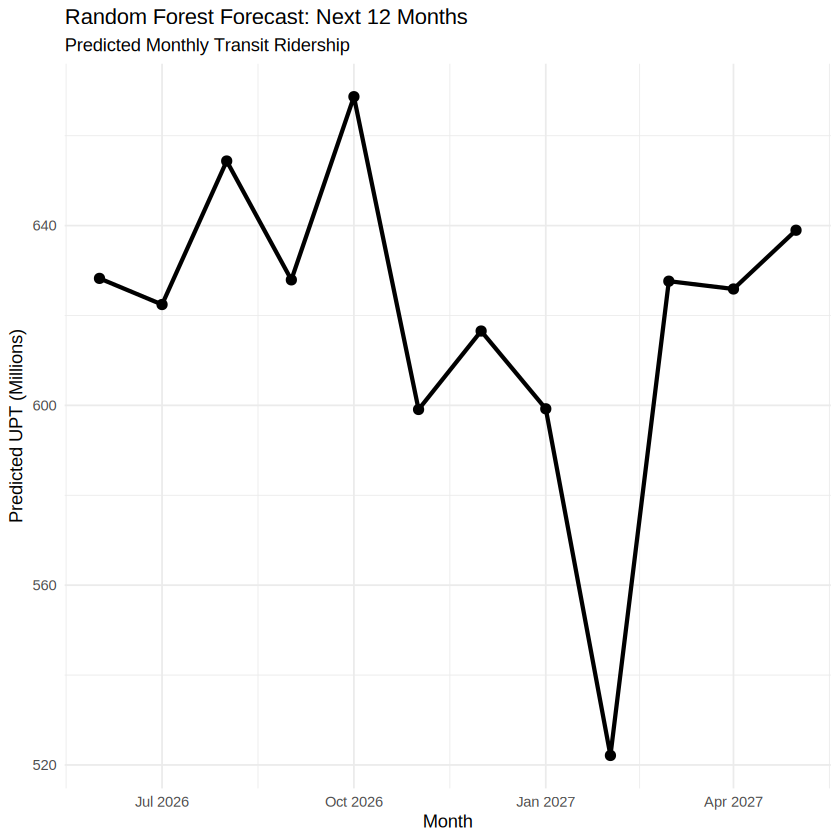

In [ ]:
#Plot Next 12 Months Forecast

ggplot(future_df, aes(x = date, y = Predicted_UPT_Millions)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Random Forest Forecast: Next 12 Months",
    subtitle = "Predicted Monthly Transit Ridership",
    x = "Month",
    y = "Predicted UPT (Millions)"
  ) +
  theme_minimal()

We retrained the Random Forest model using all available historical data and predicted ridership month by month for the next 12 months. Previous predictions were used to create the required lag values.

We plotted the historical ridership and the next 12-month Random Forest forecast to clearly show the expected future trend.

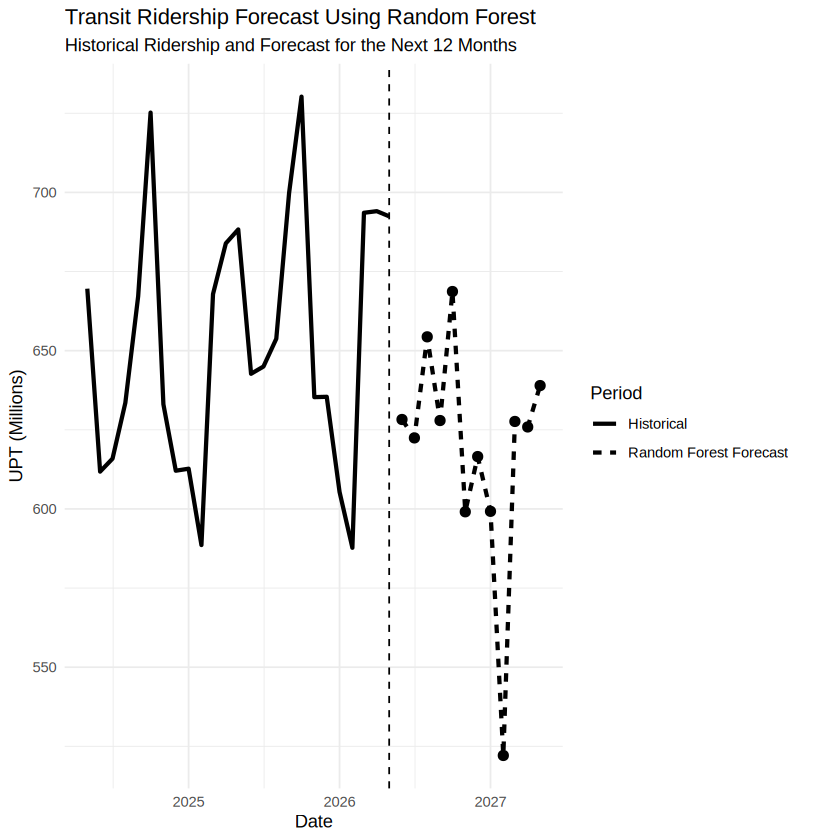

In [ ]:
#Historical + Future Forecast

historical_plot <- national_monthly %>%
  filter(date >= max(date) %m-% months(24)) %>%
  transmute(
    date = date,
    Ridership_Millions = total_upt / 1e6,
    Type = "Historical"
  )

future_plot <- future_df %>%
  transmute(
    date = date,
    Ridership_Millions = Predicted_UPT_Millions,
    Type = "Random Forest Forecast"
  )

forecast_plot_df <- bind_rows(
  historical_plot,
  future_plot
)

ggplot(
  forecast_plot_df,
  aes(x = date, y = Ridership_Millions, linetype = Type)
) +
  geom_line(linewidth = 1.2) +
  geom_point(
    data = future_plot,
    size = 2.5
  ) +
  geom_vline(
    xintercept = max(national_monthly$date),
    linetype = "dashed"
  ) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Transit Ridership Forecast Using Random Forest",
    subtitle = "Historical Ridership and Forecast for the Next 12 Months",
    x = "Date",
    y = "UPT (Millions)",
    linetype = "Period"
  ) +
  theme_minimal()

Random Forest was selected based on its performance during the 24-month holdout evaluation. The final model was retrained using the available historical data and used to forecast monthly transit ridership for the next 12 months.